# Regresiones espurias en series de tiempo

## Objetivos de aprendizaje

Al finalizar este laboratorio podrás:

- explicar por qué dos caminatas aleatorias independientes pueden parecer relacionadas en niveles;
- interpretar una regresión OLS y sus pruebas bajo no estacionariedad;
- estimar mediante Monte Carlo la frecuencia de falsos positivos;
- contrastar la regresión en niveles con una regresión en primeras diferencias y reconocer los límites de esa comparación.

## Problema y estrategia

Este experimento genera dos series sintéticas cuyos incrementos son independientes. La pregunta es si una pendiente significativa en niveles aporta evidencia de relación cuando las series no son estacionarias. Se contrasta la distribución de pruebas OLS en una simulación Monte Carlo y se repite una sola regresión con primeras diferencias.

## Datos y configuración

No se utiliza un dataset externo: ambas caminatas se simulan con la semilla `RANDOM_STATE`, longitud `T` y número de repeticiones indicados en la celda de configuración. La regresión describe asociación estadística en la muestra; no se ha definido un problema predictivo ni una variable causal.

## Configuración del experimento

Se fija `RANDOM_STATE` para reproducir las innovaciones, `T` para la longitud de cada caminata y `N_REPETITIONS` para el Monte Carlo. `ALPHA` es el umbral nominal de significancia; bajo la hipótesis nula, se espera aproximadamente esa fracción de rechazos a largo plazo, aunque una simulación finita fluctúa.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

RANDOM_STATE = 42
T = 500
N_REPETITIONS = 500
ALPHA = 0.05

rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style='whitegrid')

print(f'T = {T}; repeticiones Monte Carlo = {N_REPETITIONS}; alpha = {ALPHA}')

T = 500; repeticiones Monte Carlo = 500; alpha = 0.05


## Simular caminatas aleatorias independientes

Cada serie es la suma acumulada de innovaciones independientes con media cero. La independencia está en los incrementos; las series en niveles son persistentes y no estacionarias. Esta diferencia entre proceso generador y trayectoria observada es la clave del experimento.

In [2]:
innovations_x = rng.normal(loc=0, scale=1, size=T)
innovations_y = rng.normal(loc=0, scale=1, size=T)

random_walk_x = np.cumsum(innovations_x)
random_walk_y = np.cumsum(innovations_y)

random_walks = pd.DataFrame({
    'X': random_walk_x,
    'Y': random_walk_y,
})

print('Correlacion entre innovaciones:', np.corrcoef(innovations_x, innovations_y)[0, 1].round(4))
random_walks.head()

Correlacion entre innovaciones: -0.0088


,X,Y
0,0.304717,1.363862
1,-0.735267,2.259047
2,0.015184,1.539567
3,0.955749,0.037064
4,-0.995286,-2.927465


## Exploración de las series y correlación en niveles

El gráfico muestra dos trayectorias acumuladas independientes y su dispersión conjunta. Una tendencia visual compartida o correlación muestral distinta de cero no demuestra conexión entre los procesos; contrasta la trayectoria con la independencia de sus innovaciones.

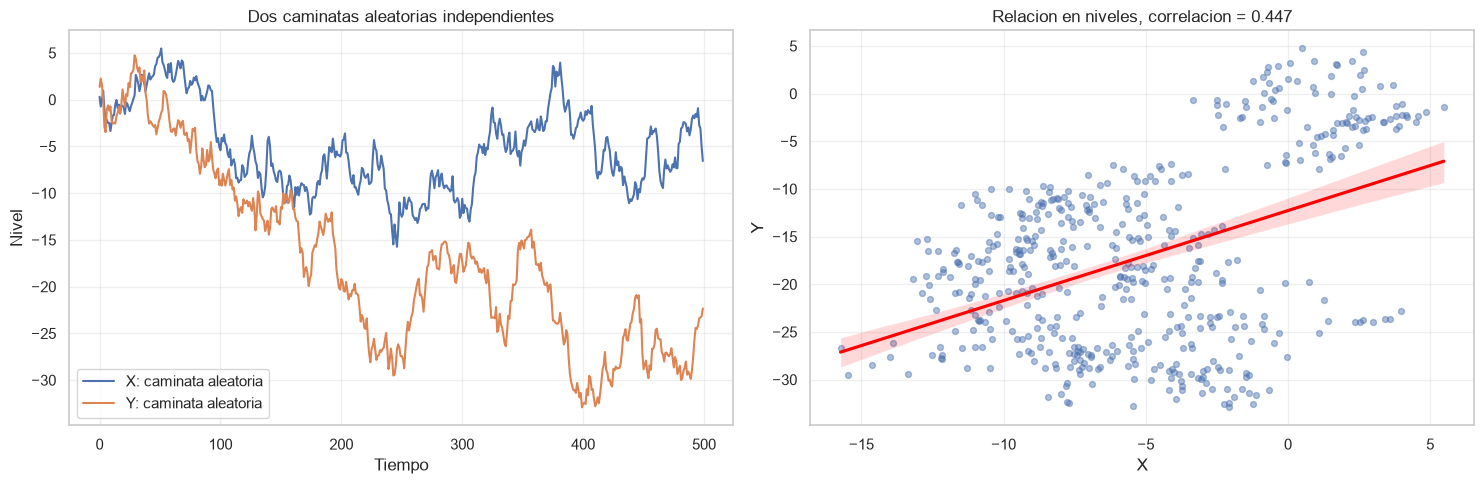

Correlacion contemporanea en niveles: 0.4475


In [3]:
level_correlation = random_walks['X'].corr(random_walks['Y'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(random_walks.index, random_walks['X'], label='X: caminata aleatoria')
axes[0].plot(random_walks.index, random_walks['Y'], label='Y: caminata aleatoria')
axes[0].set_title('Dos caminatas aleatorias independientes')
axes[0].set_xlabel('Tiempo')
axes[0].set_ylabel('Nivel')
axes[0].legend()
axes[0].grid(alpha=0.3)

sns.regplot(
    data=random_walks,
    x='X',
    y='Y',
    ax=axes[1],
    scatter_kws={'alpha': 0.45, 's': 18},
    line_kws={'color': 'red'},
)
axes[1].set_title(f'Relacion en niveles, correlacion = {level_correlation:.3f}')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Correlacion contemporanea en niveles: {level_correlation:.4f}')

## Regresión en niveles

La OLS estima la asociación muestral entre dos niveles no estacionarios. Revisa pendiente, intervalos, p-value y R² como salidas del ajuste actual. Las pruebas t/F clásicas presuponen condiciones que las caminatas no satisfacen; una aparente significancia no es evidencia válida de relación estructural.

In [4]:
X_levels = sm.add_constant(random_walks[['X']])
levels_model = sm.OLS(random_walks['Y'], X_levels).fit()

levels_coefficients = pd.DataFrame({
    'coef': levels_model.params,
    'std_error': levels_model.bse,
    't_stat': levels_model.tvalues,
    'p_value': levels_model.pvalues,
    'ci_low': levels_model.conf_int()[0],
    'ci_high': levels_model.conf_int()[1],
})

print('Resultados OLS en niveles: Y_t ~ const + X_t')
display(levels_coefficients.round(4))
print(f'R2 en niveles: {levels_model.rsquared:.4f}')
print(f'F-statistic: {levels_model.fvalue:.4f}; p-value F: {levels_model.f_pvalue:.6g}')

print('\nResumen estadistico completo:')
print(levels_model.summary())

Resultados OLS en niveles: Y_t ~ const + X_t


,coef,std_error,t_stat,p_value,ci_low,ci_high
const,-12.2652,0.5834,-21.0246,0.0,-13.4114,-11.1191
X,0.9442,0.0846,11.1668,0.0,0.7781,1.1103


R2 en niveles: 0.2003
F-statistic: 124.6967; p-value F: 5.42193e-26

Resumen estadistico completo:
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.199
Method:                 Least Squares   F-statistic:                     124.7
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           5.42e-26
Time:                        15:18:30   Log-Likelihood:                -1784.0
No. Observations:                 500   AIC:                             3572.
Df Residuals:                     498   BIC:                             3581.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

## Monte Carlo: frecuencia de rechazos

Se repite la regresión con pares de caminatas independientes para estudiar la distribución de p-values y R² bajo la hipótesis nula. Compara la proporción simulada de p-values menores que `ALPHA` con el nivel nominal; no se fija de antemano una tasa observada.

Proporcion de slopes significativos (p < 0.05): 0.888
Distribucion de p-valores:


count    500.0000
mean       0.0460
std        0.1612
min        0.0000
25%        0.0000
50%        0.0000
75%        0.0000
max        0.9996
Name: p_value_slope, dtype: float64

Distribucion de R2:


count    500.0000
mean       0.2345
std        0.2206
min        0.0000
25%        0.0384
50%        0.1652
75%        0.3764
max        0.8684
Name: r2, dtype: float64

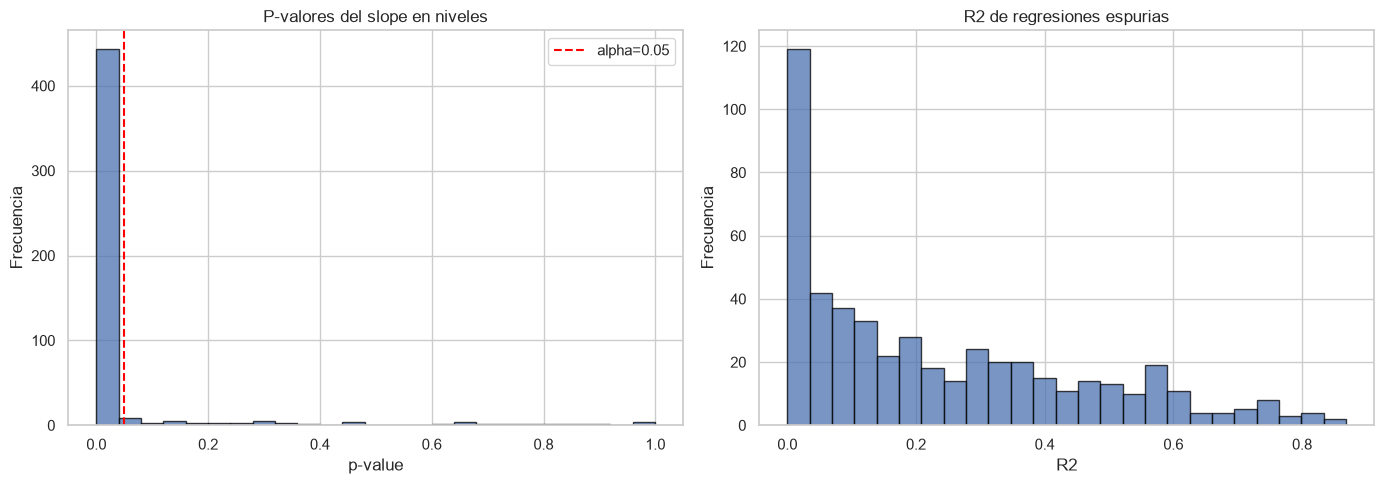

In [5]:
monte_carlo_rng = np.random.default_rng(RANDOM_STATE + 1)
monte_carlo_records = []

for repetition in range(N_REPETITIONS):
    x_sim = np.cumsum(monte_carlo_rng.normal(size=T))
    y_sim = np.cumsum(monte_carlo_rng.normal(size=T))
    simulation_model = sm.OLS(y_sim, sm.add_constant(x_sim)).fit()

    monte_carlo_records.append({
        'repetition': repetition,
        'slope': simulation_model.params[1],
        'p_value_slope': simulation_model.pvalues[1],
        'r2': simulation_model.rsquared,
    })

monte_carlo_results = pd.DataFrame(monte_carlo_records)
significant_rate = (monte_carlo_results['p_value_slope'] < ALPHA).mean()

print(f'Proporcion de slopes significativos (p < {ALPHA}): {significant_rate:.3f}')
print('Distribucion de p-valores:')
display(monte_carlo_results['p_value_slope'].describe().round(4))
print('Distribucion de R2:')
display(monte_carlo_results['r2'].describe().round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(monte_carlo_results['p_value_slope'], bins=25, edgecolor='black', alpha=0.75)
axes[0].axvline(ALPHA, color='red', linestyle='--', label=f'alpha={ALPHA}')
axes[0].set_title('P-valores del slope en niveles')
axes[0].set_xlabel('p-value')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

axes[1].hist(monte_carlo_results['r2'], bins=25, edgecolor='black', alpha=0.75)
axes[1].set_title('R2 de regresiones espurias')
axes[1].set_xlabel('R2')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## Primeras diferencias

Diferenciar cada caminata elimina su nivel acumulado y deja las innovaciones. La regresión de diferencias ilustra qué cambia al modelar incrementos estacionarios; diferenciar no es una receta universal y debe justificarse según el proceso y la pregunta analítica.

In [6]:
differences = random_walks.diff().dropna()

X_differences = sm.add_constant(differences[['X']])
differences_model = sm.OLS(differences['Y'], X_differences).fit()

differences_coefficients = pd.DataFrame({
    'coef': differences_model.params,
    'std_error': differences_model.bse,
    't_stat': differences_model.tvalues,
    'p_value': differences_model.pvalues,
    'ci_low': differences_model.conf_int()[0],
    'ci_high': differences_model.conf_int()[1],
})

print('Resultados OLS en primeras diferencias: Delta Y_t ~ const + Delta X_t')
display(differences_coefficients.round(4))
print(f'R2 en diferencias: {differences_model.rsquared:.4f}')
print(f'F-statistic: {differences_model.fvalue:.4f}; p-value F: {differences_model.f_pvalue:.6g}')

Resultados OLS en primeras diferencias: Delta Y_t ~ const + Delta X_t


,coef,std_error,t_stat,p_value,ci_low,ci_high
const,-0.0476,0.0456,-1.0444,0.2968,-0.1372,0.042
X,-0.0103,0.0475,-0.2163,0.8288,-0.1036,0.083


R2 en diferencias: 0.0001
F-statistic: 0.0468; p-value F: 0.828825


## Comparación e interpretación

Contrasta coeficiente, p-value y R² entre niveles y diferencias. La simulación muestra un mecanismo por el que dos series sin relación pueden producir una regresión engañosa en niveles; no prueba que toda relación entre series integradas sea espuria ni reemplaza un análisis de cointegración cuando corresponda.

In [7]:
comparison = pd.DataFrame([
    {
        'modelo': 'Niveles',
        'slope': levels_model.params['X'],
        'p_value_slope': levels_model.pvalues['X'],
        'R2': levels_model.rsquared,
        'F_p_value': levels_model.f_pvalue,
        'significativo_alpha_5': levels_model.pvalues['X'] < ALPHA,
    },
    {
        'modelo': 'Primeras diferencias',
        'slope': differences_model.params['X'],
        'p_value_slope': differences_model.pvalues['X'],
        'R2': differences_model.rsquared,
        'F_p_value': differences_model.f_pvalue,
        'significativo_alpha_5': differences_model.pvalues['X'] < ALPHA,
    },
])

display(comparison.round(6))

print('Conclusiones:')
print('- En niveles, una pendiente significativa y un R2 alto pueden aparecer aunque X e Y sean independientes.')
print('- En diferencias, los shocks independientes deben producir una pendiente cercana a cero y perder significancia.')
print('- La simulacion Monte Carlo cuantifica cuantas veces una regresion en niveles declara significancia por azar.')

,modelo,slope,p_value_slope,R2,F_p_value,significativo_alpha_5
0,Niveles,0.944185,0.000000,0.200253,0.000000,True
1,Primeras diferencias,-0.010275,0.828825,0.000094,0.828825,False


Conclusiones:
- En niveles, una pendiente significativa y un R2 alto pueden aparecer aunque X e Y sean independientes.
- En diferencias, los shocks independientes deben producir una pendiente cercana a cero y perder significancia.
- La simulacion Monte Carlo cuantifica cuantas veces una regresion en niveles declara significancia por azar.


## Conclusiones

Describe la tasa de falsos rechazos observada en esta ejecución y compárala con `ALPHA`, sin generalizar más allá de las repeticiones y longitud simuladas. Explica qué cambia entre niveles y diferencias, y por qué las pruebas OLS usuales no validan una relación entre caminatas independientes. Para series reales integradas, se requieren diagnósticos y preguntas adicionales, como pruebas de raíz unitaria y cointegración.

## Ejercicios propuestos

1. **Conceptual:** explica por qué independencia de innovaciones no implica trayectorias visualmente independientes en niveles.
2. **Implementación:** cambia `T` y vuelve a estimar la tasa de pendientes significativas manteniendo fija la seed.
3. **Experimentación:** aumenta `N_REPETITIONS` y observa la variabilidad de la tasa de rechazo alrededor de `ALPHA`.
4. **Análisis:** compara distribución de R² y p-values en niveles y diferencias; no interpretes un único resultado como ley universal.
5. **Desafío:** investiga qué hipótesis contrasta una prueba de cointegración y cuándo sería apropiada para dos series reales.

## Referencias

- Granger, C. W. J. y Newbold, P. (1974). Spurious regressions in econometrics. *Journal of Econometrics*, 2(2), 111-120. https://doi.org/10.1016/0304-4076(74)90034-7
- [Ordinary Least Squares en statsmodels](https://www.statsmodels.org/stable/regression.html)
- Phillips, P. C. B. (1986). Understanding spurious regressions in econometrics. *Journal of Econometrics*, 33(3), 311-340. https://doi.org/10.1016/0304-4076(86)90001-1